---
title: "simplex"
execute:
  # echo: false
  freeze: auto  # re-render only when source changes
format:
  html:
    code-fold: true
    code-summary: "Show the code"
---

In [6]:
#| code-summary: "import libraries"
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

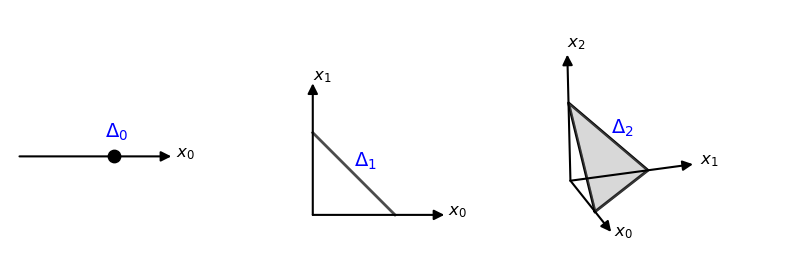

In [19]:
#| code-summary: "plot simplex"
# --- Custom class for 3D arrows ---
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

# --- Styles ---
arrow_prop = dict(mutation_scale=15, arrowstyle='-|>', color='black', linewidth=1.5, shrinkA=0, shrinkB=0)
label_font = {'fontsize': 12, 'fontweight': 'bold'}
delta_font = {'fontsize': 14, 'color': 'blue'}

fig = plt.figure(figsize=(8, 3), tight_layout=True)
fig.subplots_adjust(wspace=0)

# ------------------------------------------
# Delta_0 (0-Simplex)
# ------------------------------------------
ax0 = fig.add_subplot(131)
ax0.scatter(1, 0, color='black', s=80, zorder=3)
ax0.add_patch(FancyArrowPatch((0, 0), (1.6, 0), **arrow_prop))

# Labels
ax0.text(1.65, 0, r'$x_0$', **label_font)
ax0.text(0.9, 0.2, r'$\Delta_0$', **delta_font)

ax0.set_xlim(-0.1, 2.5); ax0.set_ylim(-0.5, 1)
ax0.set_aspect('equal'); ax0.axis('off')

# ------------------------------------------
# Delta_1 (1-Simplex)
# ------------------------------------------
ax1 = fig.add_subplot(132)
v_2d = np.eye(2)
ax1.plot([1, 0], [0, 1], color="black", linewidth=2, zorder=2, alpha=0.7)
# ax1.fill_between([0, 1], [1, 0], alpha=0.3, color='gray')

ax1.add_patch(FancyArrowPatch((0, 0), (1.6, 0), **arrow_prop)) # x0
ax1.add_patch(FancyArrowPatch((0, 0), (0, 1.6), **arrow_prop)) # x1

# Labels
ax1.text(1.65, 0, r'$x_0$', **label_font)
ax1.text(0, 1.65, r'$x_1$', **label_font)
ax1.text(0.5, 0.6, r'$\Delta_1$', **delta_font)

ax1.set_xlim(-0.5, 2.5); ax1.set_ylim(-0.5, 2.5)
ax1.set_aspect('equal'); ax1.axis('off')

# ------------------------------------------
# Delta_2 (2-Simplex)
# ------------------------------------------
ax2 = fig.add_subplot(133, projection='3d')
x = np.eye(3)

# Simplex
triangle = np.array([x[0], x[1], x[2], x[0]])
ax2.plot(*triangle.T, color="black", linewidth=2)
ax2.add_collection3d(Poly3DCollection([[x[0], x[1], x[2]]], alpha=0.3, color="gray"))

# Axes
ax2.add_artist(Arrow3D([0, 1.6], [0, 0], [0, 0], **arrow_prop))
ax2.add_artist(Arrow3D([0, 0], [0, 1.6], [0, 0], **arrow_prop))
ax2.add_artist(Arrow3D([0, 0], [0, 0], [0, 1.6], **arrow_prop))

# Labels (using 3D coordinates)
ax2.text(1.7, 0, 0, r'$x_0$', **label_font)
ax2.text(0, 1.7, 0, r'$x_1$', **label_font)
ax2.text(0, 0, 1.7, r'$x_2$', **label_font)
ax2.text(0.4, 0.4, 0.7, r'$\Delta_2$', **delta_font)

ax2.set_xlim(0, 1.7); ax2.set_ylim(0, 1.7); ax2.set_zlim(0, 1.7)
ax2.set_box_aspect([1, 1, 1])
ax2.view_init(elev=20, azim=-20)
ax2.set_axis_off()

plt.show()